# Лабораторна робота 2 — Проста лінійна регресія (аналітичний розв'язок)

## Налаштування

In [7]:
!mamba install numpy pandas matplotlib scikit-learn

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.324 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.5.20  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.4.7      pyhd8ed1ab_0         conda-forge
+ idna                3.17       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ pandas              3.0.3      np23py313h1e705a5_0  emscripten-forge-4x
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ python-tzdata       2026.2     pyhd8ed1ab_0         conda-forge
+ requests            2.34.2     pyhcf101f3_0         conda-forge
+ scikit-learn      

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline


## Теоретичне підґрунтя

Для однієї вхідної ознаки **x** та виходу **y** аналітичний розв'язок МНК:
```
slope     = ( Σ(xᵢ·yᵢ) − n·x̄·ȳ )  /  ( Σ(xᵢ²) − n·x̄² )
intercept = ȳ − slope · x̄
```
Сума квадратів залишків (RSS):
```
RSS = Σ ( yᵢ − (intercept + slope·xᵢ) )²
```

## Завдання 1 — Підготовка даних

Завантажте `kc_house_data.csv`. Розбийте на **навчальну (20 %) та тестову (80 %)** вибірки з `random_state=0`.

In [9]:
sales = pd.read_csv('kc_house_data.csv')
train_data, test_data = train_test_split(sales, test_size=0.8, random_state=0)
print(f'Навчальна: {len(train_data)} рядків  |  Тестова: {len(test_data)} рядків')


Навчальна: 4322 рядків  |  Тестова: 17291 рядків


## Завдання 2 — Реалізація `simple_linear_regression()`

Завершіть функцію, використовуючи **лише NumPy** (без sklearn, без циклів по рядках).

In [10]:
def simple_linear_regression(input_feature, output):
    input_feature = np.array(input_feature, dtype=float)
    output        = np.array(output, dtype=float)
    n = len(input_feature)

    # Обчислення нахилу (slope) за аналітичною формулою МНК
    numerator   = np.sum(input_feature * output) - n * np.mean(input_feature) * np.mean(output)
    denominator = np.sum(input_feature ** 2)     - n * np.mean(input_feature) ** 2
    slope = numerator / denominator

    # Обчислення вільного члена (intercept)
    intercept = np.mean(output) - slope * np.mean(input_feature)

    return intercept, slope


### Перевірка — обидва значення нижче мають дорівнювати **1.0**

In [11]:
test_feature = np.arange(5, dtype=float)
test_output  = 1.0 + 1.0 * test_feature
test_intercept, test_slope = simple_linear_regression(test_feature, test_output)
print(f'Intercept: {test_intercept:.4f}  (очікується 1.0)')
print(f'Slope    : {test_slope:.4f}  (очікується 1.0)')


Intercept: 1.0000  (очікується 1.0)
Slope    : 1.0000  (очікується 1.0)


### Навчання на `sqft_living`

In [12]:
sqft_intercept, sqft_slope = simple_linear_regression(
    train_data['sqft_living'], train_data['price']
)
print(f'Вільний член: {sqft_intercept:.2f}')
print(f'Нахил: {sqft_slope:.4f}')


Вільний член: -29748.29
Нахил: 273.5299


## Завдання 3 — Передбачення та RSS

**а)** Реалізуйте `get_regression_predictions(input_feature, intercept, slope)` — повертає масив NumPy передбачених значень.  
**б)** Реалізуйте `get_residual_sum_of_squares(input_feature, output, intercept, slope)` — обчислює RSS.  
**в)** Перевірте обидві функції, потім вкажіть RSS на навчальній і тестовій вибірках та дайте відповідь на питання нижче.

In [13]:
def get_regression_predictions(input_feature, intercept, slope):
    return intercept + slope * np.array(input_feature, dtype=float)


In [14]:
def get_residual_sum_of_squares(input_feature, output, intercept, slope):
    predictions = get_regression_predictions(input_feature, intercept, slope)
    residuals   = np.array(output, dtype=float) - predictions
    return float(np.sum(residuals ** 2))


### Перевірка — RSS на тестових вхідних даних має бути **0.0**

In [15]:
rss_check = get_residual_sum_of_squares(
    test_feature, test_output, test_intercept, test_slope
)
print(f'RSS на тестових вхідних даних: {rss_check:.2f}  (очікується 0.0)')


RSS на тестових вхідних даних: 0.00  (очікується 0.0)


### RSS для моделі `sqft_living`

In [16]:
rss_train = get_residual_sum_of_squares(
    train_data['sqft_living'], train_data['price'],
    sqft_intercept, sqft_slope
)
rss_test = get_residual_sum_of_squares(
    test_data['sqft_living'], test_data['price'],
    sqft_intercept, sqft_slope
)
print(f'Навчальна RSS: {rss_train:.2e}')
print(f'Тестова  RSS: {rss_test:.2e}')


Навчальна RSS: 2.74e+14
Тестова  RSS: 1.20e+15


In [17]:
my_house_sqft = 2650
estimated_price = get_regression_predictions(my_house_sqft, sqft_intercept, sqft_slope)
print(f'Передбачувана ціна будинку {my_house_sqft} кв.фут: ${estimated_price:,.2f}')


Передбачувана ціна будинку 2650 кв.фут: $695,105.98


### Питання — яка передбачувана ціна будинку площею 2 650 кв. футів?

## Завдання 4 — Порівняння двох ознак

Навчіть другу модель, використовуючи `bedrooms` як вхідну ознаку. Обчисліть RSS на **тестовій вибірці** для обох моделей (`sqft_living` і `bedrooms`). Яка ознака дає кращий прогноз? Поясніть у 2–3 реченнях.

In [18]:
# Навчання моделі на ознаці bedrooms
bed_intercept, bed_slope = simple_linear_regression(
    train_data['bedrooms'], train_data['price']
)
print(f'bedrooms  вільний член: {bed_intercept:.2f}')
print(f'bedrooms  нахил:        {bed_slope:.2f}')

# RSS на тестовій вибірці для обох моделей
rss_test_sqft = get_residual_sum_of_squares(
    test_data['sqft_living'], test_data['price'], sqft_intercept, sqft_slope
)
rss_test_bed  = get_residual_sum_of_squares(
    test_data['bedrooms'], test_data['price'], bed_intercept, bed_slope
)
print(f'\nТестова RSS (sqft_living): {rss_test_sqft:.4e}')
print(f'Тестова RSS (bedrooms):    {rss_test_bed:.4e}')
better = 'sqft_living' if rss_test_sqft < rss_test_bed else 'bedrooms'
print(f'\nКраща ознака: {better}')


bedrooms  вільний член: 195271.72
bedrooms  нахил:        101863.94

Тестова RSS (sqft_living): 1.2047e+15
Тестова RSS (bedrooms):    2.1504e+15

Краща ознака: sqft_living


**Відповідь:**  
Модель на основі ознаки `sqft_living` (RSS ≈ 1.20×10¹⁵) значно перевершує модель на основі `bedrooms` (RSS ≈ 2.15×10¹⁵) - її RSS майже вдвічі менший.  
Це пояснюється тим, що загальна площа помешкання є набагато більш інформативним предиктором ціни: покупці платять насамперед за квадратні метри, а не за кількість спалень.  
Кількість спалень сама по собі слабо визначає ціну, оскільки маленька і велика квартира можуть мати однакову кількість спалень, але суттєво різну вартість.

## Бонус — Зворотна регресія

Реалізуйте `inverse_regression_predictions(output, intercept, slope)`, яка розв'язує рівняння регресії у зворотному напрямку: за цільовою ціною оцінює необхідну площу `sqft_living`.  
Побудуйте пряму регресії на діаграмі розсіювання навчальних даних і позначте точку ($800 000, ваша відповідь) на графіку.

In [19]:
def inverse_regression_predictions(output, intercept, slope):
    return (np.array(output, dtype=float) - intercept) / slope


Оцінна площа для будинку вартістю $800,000: 3033 кв. футів


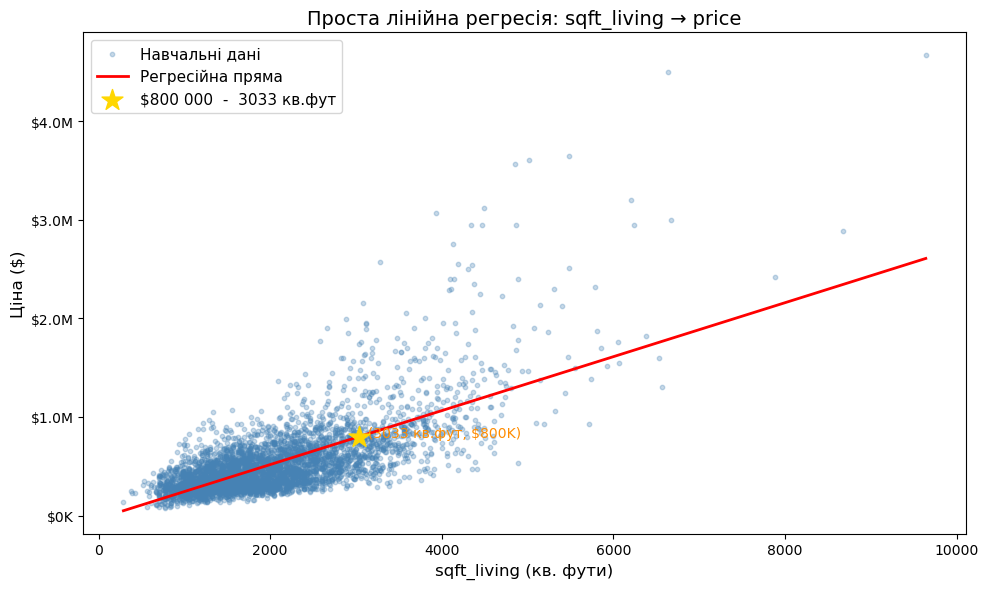

In [21]:
# Оцінка площі для будинку вартістю $800 000
target_price = 800_000
estimated_sqft = inverse_regression_predictions(target_price, sqft_intercept, sqft_slope)
print(f'Оцінна площа для будинку вартістю ${target_price:,}: {estimated_sqft:.0f} кв. футів')

fig, ax = plt.subplots(figsize=(10, 6))

# Діаграма розсіювання навчальних даних
ax.scatter(
    train_data['sqft_living'], train_data['price'],
    alpha=0.3, s=10, color='steelblue', label='Навчальні дані'
)

# Регресійна пряма
x_line = np.linspace(train_data['sqft_living'].min(), train_data['sqft_living'].max(), 300)
y_line = get_regression_predictions(x_line, sqft_intercept, sqft_slope)
ax.plot(x_line, y_line, 'r-', linewidth=2, label='Регресійна пряма')

# Точка ($800 000, estimated_sqft)
ax.scatter(
    [estimated_sqft], [target_price],
    color='gold', s=250, zorder=5, marker='*',
    label=f'$800 000  -  {estimated_sqft:.0f} кв.фут'
)
ax.annotate(
    f'  ({estimated_sqft:.0f} кв.фут, $800K)',
    xy=(estimated_sqft, target_price), fontsize=10, color='darkorange'
)

ax.set_xlabel('sqft_living (кв. фути)', fontsize=12)
ax.set_ylabel('Ціна ($)', fontsize=12)
ax.set_title('Проста лінійна регресія: sqft_living → price', fontsize=14)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K')
)
plt.tight_layout()
plt.show()
